# Module 1: Ground Truth Data Model and Baseline KPI

This notebook is the authoritative Module 1 build for the project. It prepares a financially consistent transaction table, rolls SKU data up to `COMMODITY_DESC`, isolates organic baskets for MBA, and computes the baseline diversity metrics used downstream by ALS, MBA, and uplift scoring.

Outputs written to `data/02_processed/`:
- `master_transactions.parquet`
- `master_transactions_all.parquet`
- `master_transactions_organic_only.parquet`
- `user_diversity_scores.parquet`

Design rule:
- `SALES_VALUE` is retailer revenue, not customer out-of-pocket price.
- Discounts are normalized before use so the notebook behaves correctly whether the source CSV stores them as negative or positive values.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
from packaging.version import Version

PROJECT_ROOT = Path("..").resolve()
ROOT_DIR = PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import calculate_true_price, normalize_discount_values

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RAW_DIR = ROOT_DIR / "data" / "01_raw"
OUT_DIR = ROOT_DIR / "data" / "02_processed"
FIG_DIR = ROOT_DIR / "reports"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TX_PATH = RAW_DIR / "transaction_data.csv"
PRODUCT_PATH = RAW_DIR / "product.csv"
DEMO_PATH = RAW_DIR / "hh_demographic.csv"
MARGIN_PATH = OUT_DIR / "commodity_margin.csv"
PARQUET_COMPRESSION = "snappy"

required_paths = {
    "transaction_data": TX_PATH,
    "product": PRODUCT_PATH,
    "hh_demographic": DEMO_PATH,
}

missing_paths = [name for name, path in required_paths.items() if not path.exists()]
if missing_paths:
    print("Missing raw inputs:")
    for name in missing_paths:
        print(f"- {name}: {required_paths[name]}")
    print("Add the raw CSVs before running the transformation cells.")
else:
    print("All raw inputs are present.")
    print(f"Working directory: {ROOT_DIR}")

All raw inputs are present.
Working directory: C:\Users\dell\Downloads\New folder (9)\Data_Driven_Marketing_complete-journey


## Environment Audit

This check keeps the notebook aligned across environments. We pin the Parquet compression strategy and report the local `pandas` / `pyarrow` versions before any data export happens.

In [2]:
environment_audit = pd.DataFrame(
    {
        "package": ["pandas", "pyarrow"],
        "version": [pd.__version__, pa.__version__],
        "minimum_expected": ["2.2.0", "10.0.0"],
    }
)

environment_audit["meets_minimum"] = [
    Version(pd.__version__) >= Version("2.2.0"),
    Version(pa.__version__) >= Version("10.0.0"),
]

display(environment_audit)
print(f"Parquet compression policy: {PARQUET_COMPRESSION}")
if not environment_audit["meets_minimum"].all():
    print("Warning: one or more library versions are below the project baseline.")


,package,version,minimum_expected,meets_minimum
0,pandas,2.3.3,2.2.0,True
1,pyarrow,21.0.0,10.0.0,True


Parquet compression policy: snappy


## Step 1.1 - Resolve the `SALES_VALUE` Trap

`SALES_VALUE` is the retailer's net revenue, not the customer's out-of-pocket cost. The notebook keeps both views separate:
- `Revenue_Retailer`: retailer revenue per unit.
- `Price_Paid_Customer`: estimated customer price per unit after removing retailer and coupon-match discounts.
- `Is_Promoted_Item`: any non-zero discount signal at the line level.

The discount columns are normalized with `abs()` after `fillna(0)` so the logic stays stable even if the raw source stores discounts as negative values.

In [3]:
tx_dtypes = {
    "household_key": "int32",
    "BASKET_ID": "int64",
    "DAY": "int32",
    "PRODUCT_ID": "int32",
    "QUANTITY": "int32",
    "SALES_VALUE": "float32",
    "STORE_ID": "int32",
    "RETAIL_DISC": "float32",
    "TRANS_TIME": "int32",
    "WEEK_NO": "int16",
    "COUPON_DISC": "float32",
    "COUPON_MATCH_DISC": "float32",
}

if missing_paths:
    raise FileNotFoundError("Missing raw inputs. Populate data/01_raw and rerun.")

tx = pd.read_csv(TX_PATH, dtype=tx_dtypes)
product = pd.read_csv(PRODUCT_PATH)
demographic = pd.read_csv(DEMO_PATH)

for col in ["RETAIL_DISC", "COUPON_DISC", "COUPON_MATCH_DISC"]:
    tx[col] = tx[col].fillna(0).abs()

valid_tx = tx.loc[tx["QUANTITY"] > 0].copy()
invalid_rows = len(tx) - len(valid_tx)

valid_tx["Revenue_Retailer_Total"] = valid_tx["SALES_VALUE"]
valid_tx["Revenue_Retailer"] = valid_tx["Revenue_Retailer_Total"] / valid_tx["QUANTITY"]
valid_tx["Price_Paid_Customer_Total"] = (
    valid_tx["SALES_VALUE"] - valid_tx["RETAIL_DISC"] - valid_tx["COUPON_MATCH_DISC"]
)
valid_tx["Price_Paid_Customer"] = valid_tx["Price_Paid_Customer_Total"] / valid_tx["QUANTITY"]
valid_tx["Guide_Shelf_Price_Per_Unit"] = valid_tx["Price_Paid_Customer"]
valid_tx["Is_Promoted_Item"] = valid_tx[["RETAIL_DISC", "COUPON_DISC", "COUPON_MATCH_DISC"]].gt(0).any(axis=1)

validation_sample = pd.concat(
    [
        valid_tx.query("RETAIL_DISC == 0 and COUPON_DISC == 0 and COUPON_MATCH_DISC == 0").head(3),
        valid_tx.query("RETAIL_DISC != 0").head(3),
        valid_tx.query("COUPON_DISC != 0").head(4),
    ],
    ignore_index=True,
).drop_duplicates().head(10)

print(f"Raw transaction rows: {len(tx):,}")
print(f"Rows with QUANTITY <= 0 removed: {invalid_rows:,}")
print(f"Remaining rows: {len(valid_tx):,}")

display(
    validation_sample[
        [
            "household_key",
            "BASKET_ID",
            "PRODUCT_ID",
            "QUANTITY",
            "SALES_VALUE",
            "RETAIL_DISC",
            "COUPON_DISC",
            "COUPON_MATCH_DISC",
            "Revenue_Retailer",
            "Price_Paid_Customer",
            "Guide_Shelf_Price_Per_Unit",
            "Is_Promoted_Item",
        ]
    ]
)


Raw transaction rows: 2,595,732
Rows with QUANTITY <= 0 removed: 14,466
Remaining rows: 2,581,266


,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,RETAIL_DISC,COUPON_DISC,COUPON_MATCH_DISC,Revenue_Retailer,Price_Paid_Customer,Guide_Shelf_Price_Per_Unit,Is_Promoted_Item
0,2375,26984851472,1033142,1,0.8200,0.0000,0.0000,0.0000,0.8200,0.8200,0.8200,False
1,2375,26984851472,1082185,1,1.2100,0.0000,0.0000,0.0000,1.2100,1.2100,1.2100,False
2,2375,26984851516,1102651,1,1.8900,0.0000,0.0000,0.0000,1.8900,1.8900,1.8900,False
3,2375,26984851472,1004906,1,1.3900,0.6000,0.0000,0.0000,1.3900,0.7900,0.7900,True
4,2375,26984851472,1036325,1,0.9900,0.3000,0.0000,0.0000,0.9900,0.6900,0.6900,True
5,2375,26984851472,8160430,1,1.5000,0.3900,0.0000,0.0000,1.5000,1.1100,1.1100,True
6,718,26985360571,830503,1,2.9900,1.0000,1.0000,0.0000,2.9900,1.9900,1.9900,True
7,718,26985360571,855325,1,1.1000,0.6900,0.4000,0.4000,1.1000,0.0100,0.0100,True
8,718,26985360571,934676,1,1.3700,0.4200,1.0000,0.0000,1.3700,0.9500,0.9500,True
9,718,26985360571,948756,3,2.1200,0.9000,0.7500,0.2500,0.7067,0.3233,0.3233,True


## Step 1.2 - Product Hierarchy Roll-Up

The project should not model on raw SKU IDs. The notebook rolls transactions up to `COMMODITY_DESC`, which is the right need-state level for grocery recommendation and reduces sparsity enough for ALS to work as a latent preference model.

A demographic join is included at the same stage so downstream notebooks have the user segment context available without repeating the merge.

In [4]:
tx_enriched = valid_tx.merge(
    product[["PRODUCT_ID", "DEPARTMENT", "COMMODITY_DESC", "SUB_COMMODITY_DESC", "BRAND"]],
    on="PRODUCT_ID",
    how="left",
    validate="many_to_one",
)

tx_enriched = tx_enriched.merge(
    demographic,
    on="household_key",
    how="left",
    validate="many_to_one",
)

tx_enriched["COMMODITY_DESC"] = tx_enriched["COMMODITY_DESC"].fillna("UNKNOWN_COMMODITY")
tx_enriched["SUB_COMMODITY_DESC"] = tx_enriched["SUB_COMMODITY_DESC"].fillna("UNKNOWN_SUB_COMMODITY")
tx_enriched["DEPARTMENT"] = tx_enriched["DEPARTMENT"].fillna("UNKNOWN_DEPARTMENT")
tx_enriched["BRAND"] = tx_enriched["BRAND"].fillna("UNKNOWN_BRAND")

tx_enriched["Basket_Is_Organic"] = ~tx_enriched.groupby("BASKET_ID")["Is_Promoted_Item"].transform("any")

if MARGIN_PATH.exists():
    commodity_margin = pd.read_csv(MARGIN_PATH)
else:
    commodity_margin = (
        tx_enriched[["COMMODITY_DESC", "DEPARTMENT", "BRAND"]]
        .drop_duplicates()
        .copy()
    )
    commodity_margin["Raw_Margin"] = np.where(
        commodity_margin["BRAND"].str.contains("PRIVATE", case=False, na=False),
        0.40,
        np.where(
            commodity_margin["BRAND"].str.contains("NATIONAL", case=False, na=False),
            0.20,
            0.30,
        ),
    )
    commodity_margin["Normalized_Margin"] = commodity_margin["Raw_Margin"].clip(0, 1)
    # Fix: ensure only one Normalized_Margin per COMMODITY_DESC (take max, mean, or first)
    commodity_margin = commodity_margin.groupby("COMMODITY_DESC", as_index=False)["Normalized_Margin"].first()
    commodity_margin.to_csv(MARGIN_PATH, index=False)

# Fix: ensure only one Normalized_Margin per COMMODITY_DESC in all cases
if "Normalized_Margin" in commodity_margin.columns:
    commodity_margin = commodity_margin.groupby("COMMODITY_DESC", as_index=False)["Normalized_Margin"].first()

tx_enriched = tx_enriched.merge(
    commodity_margin[["COMMODITY_DESC", "Normalized_Margin"]],
    on="COMMODITY_DESC",
    how="left",
    validate="many_to_one",
)
tx_enriched["Normalized_Margin"] = tx_enriched["Normalized_Margin"].fillna(tx_enriched["Normalized_Margin"].median())

commodity_audit = (
    tx_enriched.groupby("COMMODITY_DESC")["Revenue_Retailer"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "commodity_mean_revenue", "std": "commodity_std_revenue", "count": "commodity_obs"})
    .reset_index()
    )
commodity_audit["commodity_std_revenue"] = commodity_audit["commodity_std_revenue"].replace(0, np.nan)
tx_enriched = tx_enriched.merge(commodity_audit, on="COMMODITY_DESC", how="left", validate="many_to_one")
tx_enriched["Revenue_Retailer_Z"] = (
    tx_enriched["Revenue_Retailer"] - tx_enriched["commodity_mean_revenue"]
) / tx_enriched["commodity_std_revenue"]
tx_enriched["Revenue_Retailer_Outlier"] = tx_enriched["Revenue_Retailer_Z"].abs() >= 3

outlier_summary = pd.DataFrame(
    {
        "metric": ["outlier_rows", "outlier_rate", "commodities_with_outliers"],
        "value": [
            int(tx_enriched["Revenue_Retailer_Outlier"].sum()),
            float(tx_enriched["Revenue_Retailer_Outlier"].mean()),
            int(tx_enriched.loc[tx_enriched["Revenue_Retailer_Outlier"], "COMMODITY_DESC"].nunique()),
        ],
    }
)

display(outlier_summary)

master_group_cols = [
    "household_key",
    "BASKET_ID",
    "DAY",
    "WEEK_NO",
    "STORE_ID",
    "TRANS_TIME",
    "COMMODITY_DESC",
    "DEPARTMENT",
    "SUB_COMMODITY_DESC",
    "BRAND",
    "classification_1",
    "classification_2",
    "classification_3",
    "classification_4",
    "classification_5",
    "HOMEOWNER_DESC",
    "KID_CATEGORY_DESC",
]

master_transactions = (
    tx_enriched.groupby(master_group_cols, dropna=False)
    .agg(
        Total_Quantity=("QUANTITY", "sum"),
        Revenue_Retailer_Total=("Revenue_Retailer_Total", "sum"),
        Price_Paid_Customer_Total=("Price_Paid_Customer_Total", "sum"),
        Retail_Discount_Total=("RETAIL_DISC", "sum"),
        Coupon_Discount_Total=("COUPON_DISC", "sum"),
        Coupon_Match_Discount_Total=("COUPON_MATCH_DISC", "sum"),
        Normalized_Margin=("Normalized_Margin", "mean"),
        Distinct_SKU_Count=("PRODUCT_ID", "nunique"),
        Distinct_Subcommodity_Count=("SUB_COMMODITY_DESC", "nunique"),
        Revenue_Retailer_Outlier_Count=("Revenue_Retailer_Outlier", "sum"),
        Is_Promoted_Item=("Is_Promoted_Item", "max"),
        Basket_Is_Organic=("Basket_Is_Organic", "max"),
    )
    .reset_index()
    )

master_transactions["Revenue_Retailer"] = master_transactions["Revenue_Retailer_Total"] / master_transactions["Total_Quantity"]
master_transactions["Price_Paid_Customer"] = master_transactions["Price_Paid_Customer_Total"] / master_transactions["Total_Quantity"]
master_transactions_all = master_transactions.copy()
master_transactions_organic_only = master_transactions_all.loc[master_transactions_all["Basket_Is_Organic"]].copy()

sparsity_snapshot = pd.DataFrame(
    {
        "level": ["SKU", "Commodity"],
        "items": [
            tx_enriched["PRODUCT_ID"].nunique(),
            tx_enriched["COMMODITY_DESC"].nunique(),
        ],
        "interactions": [
            tx_enriched.groupby(["household_key", "PRODUCT_ID"]).ngroups,
            tx_enriched.groupby(["household_key", "COMMODITY_DESC"]).ngroups,
        ],
    }
)

sparsity_snapshot["sparsity"] = 1 - sparsity_snapshot["interactions"] / (
    tx_enriched["household_key"].nunique() * sparsity_snapshot["items"]
)

display(sparsity_snapshot)
print(f"master_transactions rows: {len(master_transactions):,}")
print(f"master_transactions_all rows: {len(master_transactions_all):,}")
print(f"master_transactions_organic_only rows: {len(master_transactions_organic_only):,}")

,metric,value
0,outlier_rows,"34,509.0000"
1,outlier_rate,0.0134
2,commodities_with_outliers,278.0000


,level,items,interactions,sparsity
0,SKU,92015,1395171,0.9939
1,Commodity,307,286548,0.6266


master_transactions rows: 2,216,946
master_transactions_all rows: 2,216,946
master_transactions_organic_only rows: 85,487


## Step 1.3 - Define the Organic Basket

An organic basket is any basket with no promoted item at all. This filter protects MBA from learning promotion-driven co-occurrence patterns that do not represent true behavioral affinity.

In [5]:
# Compute basket_promo_flag as a basket-level boolean, then keep the actual basket IDs.
basket_promo_flag = tx_enriched.groupby("BASKET_ID")["Is_Promoted_Item"].any()
organic_basket_ids = basket_promo_flag.index[~basket_promo_flag]
master_transactions_organic_only = master_transactions_all.loc[
    master_transactions_all["BASKET_ID"].isin(organic_basket_ids)
].copy()

basket_summary = pd.DataFrame(
    {
        "metric": ["total_baskets", "organic_baskets", "promo_baskets", "organic_transaction_rows"],
        "value": [
            tx_enriched["BASKET_ID"].nunique(),
            len(organic_basket_ids),
            tx_enriched["BASKET_ID"].nunique() - len(organic_basket_ids),
            len(master_transactions_organic_only),
        ],
    }
)

basket_summary["share"] = basket_summary["value"] / tx_enriched["BASKET_ID"].nunique()
display(basket_summary)

,metric,value,share
0,total_baskets,275889,1.0000
1,organic_baskets,45027,0.1632
2,promo_baskets,230862,0.8368
3,organic_transaction_rows,85487,0.3099


## Step 1.4 - Baseline Justification Metric

Basket diversity is the number of distinct `COMMODITY_DESC` values in one basket. The median value is the clearest high-level proof that cross-sell space exists and that recommendation is not just a nice-to-have.

In [6]:
basket_diversity = (
    tx_enriched.groupby("BASKET_ID")["COMMODITY_DESC"].nunique().reset_index(name="basket_diversity")
)
user_diversity = (
    tx_enriched.groupby("household_key")["COMMODITY_DESC"].nunique().reset_index(name="n_categories_purchased")
)

total_categories = tx_enriched["COMMODITY_DESC"].nunique()
user_diversity["diversity_score"] = user_diversity["n_categories_purchased"] / total_categories
user_diversity["uplift_potential"] = 1 - user_diversity["diversity_score"]

median_diversity = basket_diversity["basket_diversity"].median()
mean_diversity = basket_diversity["basket_diversity"].mean()
print(f"Median basket diversity: {median_diversity:.2f}")
print(f"Mean basket diversity: {mean_diversity:.2f}")
print(f"Total commodity categories: {total_categories:,}")

display(user_diversity.describe())


Median basket diversity: 4.00
Mean basket diversity: 6.90
Total commodity categories: 307


,household_key,n_categories_purchased,diversity_score,uplift_potential
count,"2,500.0000","2,500.0000","2,500.0000","2,500.0000"
mean,"1,250.5000",114.6192,0.3734,0.6266
std,721.8322,45.5607,0.1484,0.1484
min,1.0000,3.0000,0.0098,0.2117
25%,625.7500,83.0000,0.2704,0.5147
50%,"1,250.5000",117.0000,0.3811,0.6189
75%,"1,875.2500",149.0000,0.4853,0.7296
max,"2,500.0000",242.0000,0.7883,0.9902


## Step 1.4b - Unit Price Consistency Check

For the same `PRODUCT_ID`, `Guide_Shelf_Price_Per_Unit` should stay stable across baskets. Large dispersion is a data-quality warning because it can distort the later uplift and margin calculations.

,PRODUCT_ID,basket_count,price_mean,price_std,price_cv
35797,1085154,127,0.0003,1.1127,"3,533.0001"
76029,12385221,6,0.0033,7.7356,"2,320.6384"
41302,1135258,493,0.0016,2.7290,"1,662.1824"
77871,12605728,5,0.0020,1.9950,997.5066
59557,7130487,6,0.0033,2.3135,694.0393
33104,1061080,12,0.0075,1.7013,226.8466
16297,911409,173,0.0112,2.4482,218.3212
70207,9859064,15,0.0307,2.2053,71.9122
85349,14050409,7,0.0700,4.3044,61.4912
33004,1060279,19,0.0163,0.8951,54.8640


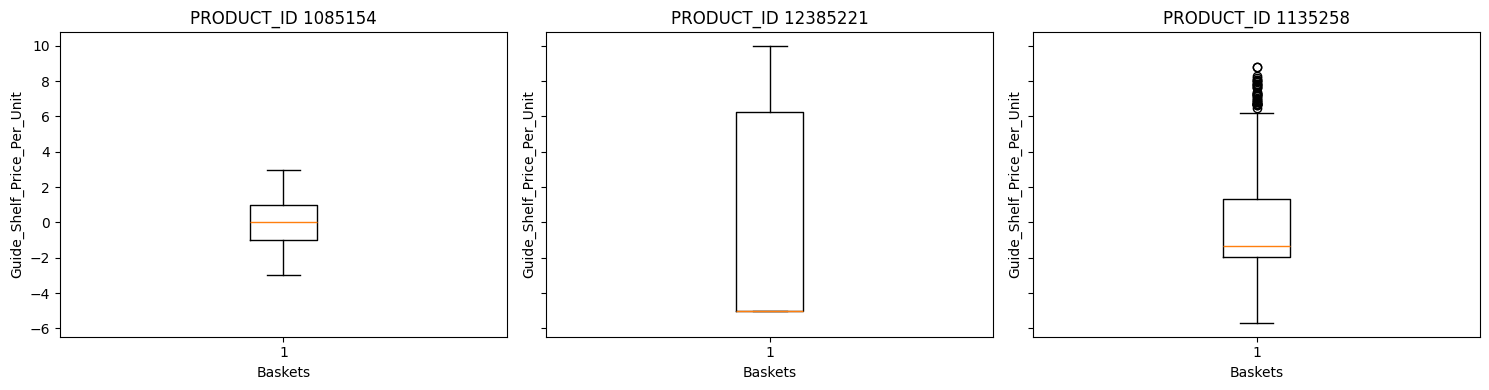

In [7]:
price_consistency = (
    tx_enriched.groupby("PRODUCT_ID")["Guide_Shelf_Price_Per_Unit"]
    .agg(["count", "mean", "std"])
    .rename(columns={"count": "basket_count", "mean": "price_mean", "std": "price_std"})
    .reset_index()
)
price_consistency = price_consistency.loc[price_consistency["basket_count"] >= 5].copy()
price_consistency["price_cv"] = price_consistency["price_std"] / price_consistency["price_mean"].replace(0, np.nan)
price_consistency = price_consistency.sort_values("price_cv", ascending=False)

suspicious_prices = price_consistency.head(10)
display(suspicious_prices)

plot_ids = suspicious_prices["PRODUCT_ID"].head(3).tolist()
if plot_ids:
    fig, axes = plt.subplots(1, len(plot_ids), figsize=(5 * len(plot_ids), 4), sharey=True)
    if len(plot_ids) == 1:
        axes = [axes]
    for ax, product_id in zip(axes, plot_ids):
        sample = tx_enriched.loc[tx_enriched["PRODUCT_ID"] == product_id, ["BASKET_ID", "Guide_Shelf_Price_Per_Unit"]].dropna()
        ax.boxplot(sample["Guide_Shelf_Price_Per_Unit"], vert=True)
        ax.set_title(f"PRODUCT_ID {product_id}")
        ax.set_xlabel("Baskets")
        ax.set_ylabel("Guide_Shelf_Price_Per_Unit")
    plt.tight_layout()
    plt.show()


## Step 1.5 - Persist Outputs and Run QA

The final block writes the processed tables and validates the semantics that matter most for downstream modules:
- the required outputs exist,
- the organic basket filter really excludes promoted baskets,
- the diversity metric is internally consistent.

,check,status
0,master_transactions_saved,PASS
1,master_transactions_all_saved,PASS
2,master_transactions_organic_only_saved,PASS
3,user_diversity_saved,PASS
4,organic_baskets_have_no_promotions,PASS
5,median_diversity_recomputes_same_value,PASS
6,margin_column_present,PASS
7,category_dtype_optimized,PASS


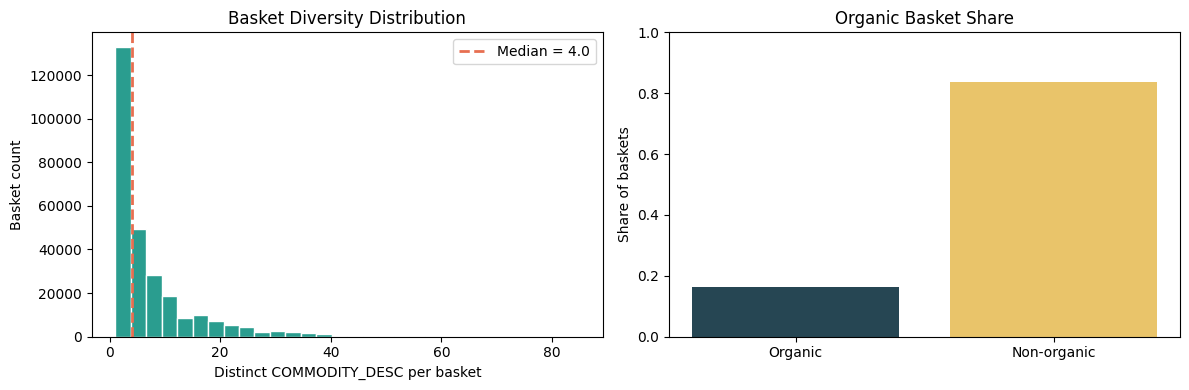

Saved: master_transactions.parquet
Saved: master_transactions_all.parquet
Saved: master_transactions_organic_only.parquet
Saved: user_diversity_scores.parquet


In [8]:
master_path = OUT_DIR / "master_transactions.parquet"
master_all_path = OUT_DIR / "master_transactions_all.parquet"
master_organic_path = OUT_DIR / "master_transactions_organic_only.parquet"
user_diversity_path = OUT_DIR / "user_diversity_scores.parquet"

categorical_columns = [
    "household_key",
    "COMMODITY_DESC",
    "DEPARTMENT",
    "SUB_COMMODITY_DESC",
    "BRAND",
    "HOMEOWNER_DESC",
    "KID_CATEGORY_DESC",
    "classification_1",
    "classification_2",
    "classification_3",
    "classification_4",
    "classification_5",
]


def optimize_output_dtypes(frame: pd.DataFrame) -> pd.DataFrame:
    optimized = frame.copy()
    for column in categorical_columns:
        if column in optimized.columns:
            optimized[column] = optimized[column].astype("category")
    if "basket_diversity" in optimized.columns:
        optimized["basket_diversity"] = pd.to_numeric(optimized["basket_diversity"], downcast="integer")
    if "n_categories_purchased" in optimized.columns:
        optimized["n_categories_purchased"] = pd.to_numeric(optimized["n_categories_purchased"], downcast="integer")
    if "Normalized_Margin" in optimized.columns:
        optimized["Normalized_Margin"] = pd.to_numeric(optimized["Normalized_Margin"], downcast="float")
    return optimized

master_transactions_out = optimize_output_dtypes(master_transactions)
master_transactions_all_out = optimize_output_dtypes(master_transactions_all)
master_transactions_organic_out = optimize_output_dtypes(master_transactions_organic_only)
user_diversity_out = optimize_output_dtypes(user_diversity)

master_transactions_out.to_parquet(master_path, index=False, compression=PARQUET_COMPRESSION)
master_transactions_all_out.to_parquet(master_all_path, index=False, compression=PARQUET_COMPRESSION)
master_transactions_organic_out.to_parquet(master_organic_path, index=False, compression=PARQUET_COMPRESSION)
user_diversity_out.to_parquet(user_diversity_path, index=False, compression=PARQUET_COMPRESSION)

qa_checks = pd.DataFrame(
    {
        "check": [
            "master_transactions_saved",
            "master_transactions_all_saved",
            "master_transactions_organic_only_saved",
            "user_diversity_saved",
            "organic_baskets_have_no_promotions",
            "median_diversity_recomputes_same_value",
            "margin_column_present",
            "category_dtype_optimized",
        ],
        "status": [
            master_path.exists(),
            master_all_path.exists(),
            master_organic_path.exists(),
            user_diversity_path.exists(),
            bool(
                tx_enriched.groupby("BASKET_ID")["Is_Promoted_Item"].max().loc[
                    master_transactions_organic_only["BASKET_ID"].unique()
                ].eq(False).all()
            ),
            float(tx_enriched.groupby("BASKET_ID")["COMMODITY_DESC"].nunique().median())
            == float(median_diversity),
            "Normalized_Margin" in master_transactions_all.columns,
            all(
                column in master_transactions_all_out.columns and str(master_transactions_all_out[column].dtype) == "category"
                for column in ["COMMODITY_DESC", "household_key"]
                if column in master_transactions_all_out.columns
            ),
        ],
    }
)
qa_checks["status"] = qa_checks["status"].map(lambda value: "PASS" if value else "FAIL")
display(qa_checks)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(basket_diversity["basket_diversity"], bins=30, color="#2a9d8f", edgecolor="white")
axes[0].axvline(median_diversity, color="#e76f51", linestyle="--", linewidth=2, label=f"Median = {median_diversity:.1f}")
axes[0].set_title("Basket Diversity Distribution")
axes[0].set_xlabel("Distinct COMMODITY_DESC per basket")
axes[0].set_ylabel("Basket count")
axes[0].legend()

organic_share = master_transactions_organic_only["BASKET_ID"].nunique() / master_transactions_all["BASKET_ID"].nunique()
axes[1].bar(["Organic", "Non-organic"], [organic_share, 1 - organic_share], color=["#264653", "#e9c46a"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Organic Basket Share")
axes[1].set_ylabel("Share of baskets")

plt.tight_layout()
plt.show()

print(f"Saved: {master_path.name}")
print(f"Saved: {master_all_path.name}")
print(f"Saved: {master_organic_path.name}")
print(f"Saved: {user_diversity_path.name}")

## Module 1 Summary

This notebook now matches the README Module 1 contract:
- financial semantics are normalized before any downstream use,
- transactions are rolled up to `COMMODITY_DESC`,
- organic baskets are isolated for MBA,
- diversity metrics are available for uplift scoring,
- processed parquet outputs are written for the next modules.

Next notebooks can read `master_transactions_organic_only.parquet` for MBA and `master_transactions_all.parquet` for ALS-style candidate generation.